In [10]:
from ..utils import *

ImportError: attempted relative import with no known parent package

## 图1

In [4]:
raws = [
    "D:/data/ms/Astral/PXD046357-Single_Cell_after/20230108_AST_Neo1_DDA_UHG_HeLa_200ng_2th2p5ms_top50_01_20230808155512.raw",
    "D:/data/ms/Astral/PXD046357-Single_Cell_after/20230108_AST_Neo1_DDA_UHG_HeLa_200ng_2th2p5ms_top50_02_20230808161140.raw",
    "D:/data/ms/Astral/PXD046357-Single_Cell_after/20230108_AST_Neo1_DDA_UHG_HeLa_200ng_2th2p5ms_top50_03_20230808162807.raw",
    "D:/data/ms/Astral/PXD046357-Single_Cell_after/20230108_AST_Neo1_DDA_UHG_HeLa_200ng_2th2p5ms_top75_01_20230808171732.raw",
    "D:/data/ms/Astral/PXD046357-Single_Cell_after/20230108_AST_Neo1_DDA_UHG_HeLa_200ng_2th2p5ms_top75_02_20230808173359.raw",
    "D:/data/ms/Astral/PXD046357-Single_Cell_after/20230108_AST_Neo1_DDA_UHG_HeLa_200ng_2th2p5ms_top75_03_20230808175026.raw",
    "D:/data/ms/Astral/PXD046357-Single_Cell_after/20230108_AST_Neo1_DDA_UHG_HeLa_200ng_2th2p5ms_top100_01.raw",
    "D:/data/ms/Astral/PXD046357-Single_Cell_after/20230108_AST_Neo1_DDA_UHG_HeLa_200ng_2th2p5ms_top100_02.raw",
    "D:/data/ms/Astral/PXD046357-Single_Cell_after/20230108_AST_Neo1_DDA_UHG_HeLa_200ng_2th2p5ms_top100_03.raw",
    "D:/data/ms/Astral/PXD046357-Single_Cell_after/20230108_AST_Neo1_DDA_UHG_HeLa_200ng_2th2p5ms_Cycle_01_20230808143253.raw",
    "D:/data/ms/Astral/PXD046357-Single_Cell_after/20230108_AST_Neo1_DDA_UHG_HeLa_200ng_2th2p5ms_Cycle_02_20230808144922.raw",
    "D:/data/ms/Astral/PXD046357-Single_Cell_after/20230108_AST_Neo1_DDA_UHG_HeLa_200ng_2th2p5ms_Cycle_03_20230808150548.raw",
]

In [6]:
pfind_res_paths = list()
diann_report_paths = list()
diann_reportlib_paths = list()
pfind_res_paths.append("D:/pFindWorkspace/Astral/after/pFindTask1-restricted-top50/result/pFind.spectra")
diann_report_paths.append("D:/DIANNWorkspace/Task1-top50-deep/report.tsv")
diann_reportlib_paths.append("D:/DIANNWorkspace/Task1-top50-deep/report-lib.tsv")
# raw_paths = raws[:3]

pfind_res_paths.append("D:/pFindWorkspace/Astral/after/pFindTask2-restricted-top75/result/pFind.spectra")
diann_report_paths.append("D:/DIANNWorkspace/Task2-top75-deep/report.tsv")
diann_reportlib_paths.append("D:/DIANNWorkspace/Task2-top75-deep/report-lib.tsv")
# raw_paths = raws[3:6]

pfind_res_paths.append("D:/pFindWorkspace/Astral/after/pFindTask3-restricted-top100/result/pFind.spectra")
diann_report_paths.append("D:/DIANNWorkspace/Task3-top100-deep/report.tsv")
diann_reportlib_paths.append("D:/DIANNWorkspace/Task3-top100-deep/report-lib.tsv")
# raw_paths = raws[6:9]


pfind_res_paths.append("D:/pFindWorkspace/Astral/after/pFindTask4-restricted-cycle/result/pFind.spectra")
diann_report_paths.append("D:/DIANNWorkspace/Task4-cycle-deep/report.tsv")
diann_reportlib_paths.append("D:/DIANNWorkspace/Task4-cycle-deep/report-lib.tsv")
# raw_paths = raws[9:]

pep_level_fdr = 0.01
ppm_level = 10
P_mass = 1.007277  # 质子相对质量
mod_ini_path = "infos/modification.ini"
mod_uni_path = "infos/unimod.obo.txt"
# pfc_paths = [path.replace('.raw', '.pfc') for path in raw_paths]
# csv_paths = [path.replace('.raw', '.csv') for path in raw_paths]
# mgf_paths = [path.replace('.raw', '_HCDAST.mgf') for path in raw_paths]

mod2unimod_id = get_mod2unimod_id(mod_ini_path, mod_uni_path)

NameError: name 'get_mod2unimod_id' is not defined

In [45]:
"""
获取pFind和DIA-NN结果(pFind结果包括通过和不通过阈值的，不包括无结果的谱图)：DIA-NN的scan号向pFind对齐，pFind的修饰向DIA-NN对齐
idx2pfind_res: pfind_idx -> [[seq,modified_seq,charge,is_decoy,cal_mh,exp_mh,q_value,protein_names]...]
idx2diann_res: pfind_idx -> [[seq,modified_seq,charge,is_decoy,cal_mz,q_value,protein_ids_str]...]
"""
group_idx2pfind_res = list()
group_idx2diann_res = list()
for i in range(4):
    pfc_paths = [path.replace('.raw', '.pfc') for path in raws[i*3:(i+1)*3]]
    ms2_diann2pfind, pfind_ms2toms1 = get_scan_mapping(pfc_paths)
    idx2pfind_res = get_pfind_result(pfind_res_paths[i], mod2unimod_id, pep_level_fdr=0.0101, scan2diann=False, scan_pfind2diann=None)
    idx2diann_res = get_diann_result(diann_report_paths[i], diann_reportlib_paths[i], scan2pfind=True, scan_diann2pfind=ms2_diann2pfind)
    group_idx2pfind_res.append(idx2pfind_res)
    group_idx2diann_res.append(idx2diann_res)

top50_01
top50_02
top50_03
top75_01
top75_02
top75_03
top100_01
top100_02
top100_03
Cycle_01
Cycle_02
Cycle_03


In [46]:
"""
获取protein_id -> protein_name的映射(都怪烦人的DIA-NN，名称也不统一)
"""
fasta_path = "D:/data/fasta/human_arabidopsis_con.fasta"
uniprot_id2pro_name = get_uniprot_id2pro_name(fasta_path)
pro2seq = get_pro2seq(fasta_path)

In [47]:
"""
获取肽段对应信息：
pep->idxs
seq->info[is_decoy,protein_names]: 这里有个很奇怪的问题——DIA-NN和pFind的seq->pro_names无法对齐，已经找到了其中三个原因：
    pFind推断蛋白质时会对I/L进行替换，找到所有可能的蛋白质；pFind有REV蛋白质；DIA-NN会少算一部分正常蛋白质
pfind_peps, diann_peps, intersect_peps......
"""
group_pfind_seqs = list()
group_diann_seqs = list()
for idx2pfind_res, idx2diann_res in zip(group_idx2pfind_res, group_idx2diann_res):
    # 通过阈值的肽段序列、修饰肽段
    pfind_seqs = set()
    for pfind_idx, infos in idx2pfind_res.items():
        for info in infos:  # 混合谱
            seq,modified_seq,charge,is_decoy,cal_mh,exp_mh,q_value,protein_names = info
            # 肽段序列
            if q_value <= pep_level_fdr and not is_decoy:
                pfind_seqs.add(seq)
    
    # 通过阈值的肽段序列、修饰肽段
    diann_seqs = set()
    for pfind_idx, infos in idx2diann_res.items():
        for info in infos:  # 混合谱
            seq,modified_seq,charge,is_decoy,cal_mz,q_value,protein_ids_str = info
            # 肽段序列
            if q_value <= pep_level_fdr and not is_decoy:
                diann_seqs.add(seq)
    group_pfind_seqs.append(pfind_seqs)
    group_diann_seqs.append(diann_seqs)

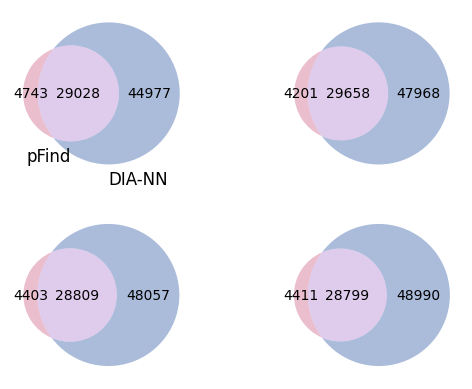

In [264]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
"""
target肽段序列数目
"""
# top50:  33771 v.s. 73886
# top75:  33859 v.s. 78157
# top100: 33212 v.s. 78310
# cycle:  33210 v.s. 78520
fig, axs = plt.subplots(2, 2)

# 绘制韦恩图
venn = venn2([group_pfind_seqs[0], group_diann_seqs[0]], ('pFind', 'DIA-NN'), ax=axs[0,0], set_colors=("#cc5d84","#2e59a7"))
# axs[0,0].set_title('Top50')
# 添加文本注释
shared_num = len(group_pfind_seqs[0] & group_diann_seqs[0])
venn.get_label_by_id('10').set_text(str(len(group_pfind_seqs[0])-shared_num))
venn.get_label_by_id('01').set_text(str(len(group_diann_seqs[0])-shared_num))
# venn.get_label_by_id('11').set_text('Set 1 and Set 2')

venn = venn2([group_pfind_seqs[1], group_diann_seqs[1]], ('', ''), ax=axs[0,1], set_colors=("#cc5d84","#2e59a7"))
# axs[0,1].set_title('Top75')
# 添加文本注释
shared_num = len(group_pfind_seqs[1] & group_diann_seqs[1])
venn.get_label_by_id('10').set_text(str(len(group_pfind_seqs[1])-shared_num))
venn.get_label_by_id('01').set_text(str(len(group_diann_seqs[1])-shared_num))

venn = venn2([group_pfind_seqs[2], group_diann_seqs[2]], ('', ''), ax=axs[1,0], set_colors=("#cc5d84","#2e59a7"))
# axs[1,0].set_title('Top100')
# 添加文本注释
shared_num = len(group_pfind_seqs[2] & group_diann_seqs[2])
venn.get_label_by_id('10').set_text(str(len(group_pfind_seqs[2])-shared_num))
venn.get_label_by_id('01').set_text(str(len(group_diann_seqs[2])-shared_num))

venn = venn2([group_pfind_seqs[3], group_diann_seqs[3]], ('', ''), ax=axs[1,1], set_colors=("#cc5d84","#2e59a7"))
# axs[1,1].set_title('Cycle')
# 添加文本注释
shared_num = len(group_pfind_seqs[3] & group_diann_seqs[3])
venn.get_label_by_id('10').set_text(str(len(group_pfind_seqs[3])-shared_num))
venn.get_label_by_id('01').set_text(str(len(group_diann_seqs[3])-shared_num))

# 显示图形
# plt.title('Venn Diagram')
plt.show()

## 图2

In [40]:
fasta_path = "D:/data/fasta/human_arabidopsis_con.fasta"

human_num = 0
arath_num = 0
con_num = 0
with open(fasta_path, "r") as f:
    for line in f:
        if line.startswith(">"):
            protein_name = line.strip().split()[0][1:]
            if protein_name.endswith("_HUMAN"):
                human_num += 1
            elif protein_name.endswith("_ARATH"):
                arath_num += 1
            elif protein_name.startswith("CON"):
                con_num += 1
            else:
                print("error!")
print(human_num, arath_num, con_num)

20435 16389 286


# 绘制target肽段 v.s. 陷阱肽段(以modified_seq为区分)

In [341]:
from utils import *

raws = [
    "D:/data/ms/Astral/PXD046357-Single_Cell_after/20230108_AST_Neo1_DDA_UHG_HeLa_200ng_2th2p5ms_top50_01_20230808155512.raw",
    "D:/data/ms/Astral/PXD046357-Single_Cell_after/20230108_AST_Neo1_DDA_UHG_HeLa_200ng_2th2p5ms_top50_02_20230808161140.raw",
    "D:/data/ms/Astral/PXD046357-Single_Cell_after/20230108_AST_Neo1_DDA_UHG_HeLa_200ng_2th2p5ms_top50_03_20230808162807.raw",
    "D:/data/ms/Astral/PXD046357-Single_Cell_after/20230108_AST_Neo1_DDA_UHG_HeLa_200ng_2th2p5ms_top75_01_20230808171732.raw",
    "D:/data/ms/Astral/PXD046357-Single_Cell_after/20230108_AST_Neo1_DDA_UHG_HeLa_200ng_2th2p5ms_top75_02_20230808173359.raw",
    "D:/data/ms/Astral/PXD046357-Single_Cell_after/20230108_AST_Neo1_DDA_UHG_HeLa_200ng_2th2p5ms_top75_03_20230808175026.raw",
    "D:/data/ms/Astral/PXD046357-Single_Cell_after/20230108_AST_Neo1_DDA_UHG_HeLa_200ng_2th2p5ms_top100_01.raw",
    "D:/data/ms/Astral/PXD046357-Single_Cell_after/20230108_AST_Neo1_DDA_UHG_HeLa_200ng_2th2p5ms_top100_02.raw",
    "D:/data/ms/Astral/PXD046357-Single_Cell_after/20230108_AST_Neo1_DDA_UHG_HeLa_200ng_2th2p5ms_top100_03.raw",
    "D:/data/ms/Astral/PXD046357-Single_Cell_after/20230108_AST_Neo1_DDA_UHG_HeLa_200ng_2th2p5ms_Cycle_01_20230808143253.raw",
    "D:/data/ms/Astral/PXD046357-Single_Cell_after/20230108_AST_Neo1_DDA_UHG_HeLa_200ng_2th2p5ms_Cycle_02_20230808144922.raw",
    "D:/data/ms/Astral/PXD046357-Single_Cell_after/20230108_AST_Neo1_DDA_UHG_HeLa_200ng_2th2p5ms_Cycle_03_20230808150548.raw",
]

# # pfind_res_path = "D:/pFindWorkspace/Astral/after/pFindTask1-restricted-top50/result/pFind.spectra"
# pfind_res_path = "D:/pFindWorkspace/Astral/after/new/top50_complete/result/pFind.spectra"
# # diann_report_path = "D:/DIANNWorkspace/DIANNTask1-deep-Astral-PXD046357-top50/report.tsv"
# # diann_reportlib_path = "D:/DIANNWorkspace/DIANNTask1-deep-Astral-PXD046357-top50/report-lib.tsv"
# diann_report_path = "D:/DIANNWorkspace/Task1-top50-deep/report.tsv"
# diann_reportlib_path = "D:/DIANNWorkspace/Task1-top50-deep/report-lib.tsv"
# raw_paths = raws[:3]

# # pfind_res_path = "D:/pFindWorkspace/Astral/after/pFindTask2-restricted-top75/result/pFind.spectra"
# pfind_res_path = "D:/pFindWorkspace/Astral/after/new/top75_complete/result/pFind.spectra"
# # diann_report_path = "D:/DIANNWorkspace/DIANNTask2-deep-Astral-PXD046357-top75/report.tsv"
# # diann_reportlib_path = "D:/DIANNWorkspace/DIANNTask2-deep-Astral-PXD046357-top75/report-lib.tsv"
# diann_report_path = "D:/DIANNWorkspace/Task2-top75-deep/report.tsv"
# diann_reportlib_path = "D:/DIANNWorkspace/Task2-top75-deep/report-lib.tsv"
# raw_paths = raws[3:6]

# # pfind_res_path = "D:/pFindWorkspace/Astral/after/pFindTask3-restricted-top100/result/pFind.spectra"
# pfind_res_path = "D:/pFindWorkspace/Astral/after/new/top100_complete/result/pFind.spectra"
# # diann_report_path = "D:/DIANNWorkspace/DIANNTask3-deep-Astral-PXD046357-top100/report.tsv"
# # diann_reportlib_path = "D:/DIANNWorkspace/DIANNTask3-deep-Astral-PXD046357-top100/report-lib.tsv"
# diann_report_path = "D:/DIANNWorkspace/Task3-top100-deep/report.tsv"
# diann_reportlib_path = "D:/DIANNWorkspace/Task3-top100-deep/report-lib.tsv"
# raw_paths = raws[6:9]

# # # diann_report_path = "D:/DIANNWorkspace/DIANNTask1-deep-Astral-PXD046357-top50/report.tsv"
# # pfind_res_path = "D:/pFindWorkspace/Astral/after/pFindTask4-restricted-cycle/result/pFind.spectra"
# pfind_res_path = "D:/pFindWorkspace/Astral/after/new/cycle_complete/result/pFind.spectra"
# # diann_report_path = "D:/DIANNWorkspace/DIANNTask4-deep-Astral-PXD046357-cycle/report.tsv"
# # diann_reportlib_path = "D:/DIANNWorkspace/DIANNTask4-deep-Astral-PXD046357-cycle/report-lib.tsv"
# diann_report_path = "D:/DIANNWorkspace/Task4-cycle-deep/report.tsv"
# diann_reportlib_path = "D:/DIANNWorkspace/Task4-cycle-deep/report-lib.tsv"
# raw_paths = raws[9:]


# pfind_res_path = "D:/pFindWorkspace/Astral/after/new/human_normal_151009_exo3_new/result/pFind.spectra"
pfind_res_path = "D:/pFindWorkspace/Astral/after/new/mann2021_human_new_/result/pFind.spectra"

pep_level_fdr = 0.01
ppm_level = 10
P_mass = 1.007277  # 质子相对质量
mod_ini_path = "infos/modification.ini"
mod_uni_path = "infos/unimod.obo.txt"
pfc_paths = [path.replace('.raw', '.pfc') for path in raw_paths]

mod2unimod_id = get_mod2unimod_id(mod_ini_path, mod_uni_path)
# ms2_diann2pfind, pfind_ms2toms1 = get_scan_mapping(pfc_paths)

# 获取pFind过滤后和DIA-NN的结果
idx2pfind_res = get_pfind_result(pfind_res_path, mod2unimod_id, pep_level_fdr=pep_level_fdr, scan2diann=False, scan_pfind2diann=None)
# idx2diann_res = get_diann_result(diann_report_path, diann_reportlib_path, scan2pfind=True, scan_diann2pfind=ms2_diann2pfind)


modified_seqs = set()
trapped_modified_seqs = set()
for pfind_idx, pfind_ress in idx2pfind_res.items():
    for pfind_res in pfind_ress:
        seq,modified_seq,charge,is_decoy,cal_mh,exp_mh,q_value,protein_names = pfind_res
        if is_decoy:
            continue
        modified_seqs.add(modified_seq)
        # 统计陷阱库肽段数目
        flag = False
        for protein_name in protein_names:
            if not protein_name.startswith("REV_") and not protein_name.endswith("_ARATH"):
                flag = True
                break
        if not flag:
            trapped_modified_seqs.add(modified_seq)
print(len(modified_seqs), len(trapped_modified_seqs))



# modified_seqs = set()
# trapped_modified_seqs = set()
# for diann_idx, diann_ress in idx2diann_res.items():
#     for diann_res in diann_ress:
#         seq,modified_seq,charge,is_decoy,cal_mz,q_value,protein_ids_str = diann_res
#         modified_seqs.add(modified_seq)
#         # 统计陷阱库肽段数目
#         protein_names = parse(protein_ids_str, uniprot_id2pro_name)
#         flag = False
#         for protein_name in protein_names:
#             if not protein_name.startswith("REV_") and not protein_name.endswith("_ARATH"):
#                 flag = True
#                 break
#         if not flag:
#             trapped_modified_seqs.add(modified_seq)
# print(len(modified_seqs), len(trapped_modified_seqs))

9377 236


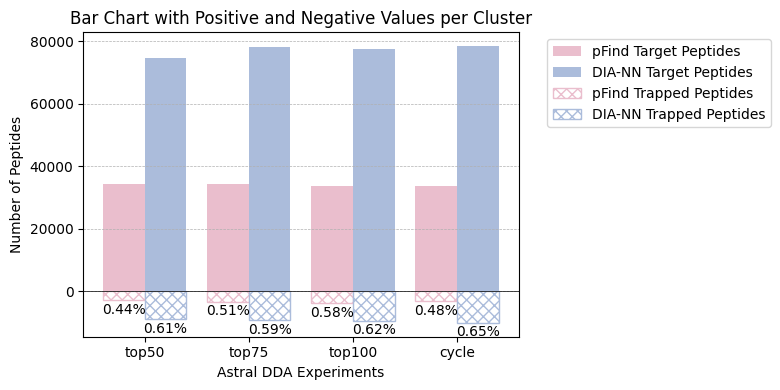

In [274]:
import numpy as np
import matplotlib.pyplot as plt

# 数据准备
clusters = 4  # 簇的数量
scaling_factor = 20
# 假设每个簇有两个柱子：一个正数柱子和一个负数柱子
pfind_positive_data = [34141, 34234, 33580, 33561]  # 正数数据
pfind_negative_data = np.array([149, 176, 196, 162])*scaling_factor  # 负数数据
diann_positive_data = [74660, 78332, 77600, 78463]  # 正数数据
diann_negative_data = np.array([452, 466, 478, 510])*scaling_factor  # 负数数据

# 柱子的宽度和位置
bar_width = 0.4  # 柱子的宽度
index = np.arange(clusters)  # X轴位置

# 创建一个图形和子图
fig, ax = plt.subplots(figsize=(8,4))

# 绘制正数柱子
ax.bar(index, pfind_positive_data, bar_width, label="pFind Target Peptides", color="#eabecd", align='center')
ax.bar(index+bar_width, diann_positive_data, bar_width, label="DIA-NN Target Peptides", color="#abbcdb", align='center')
for i in range(4):
    ax.text(0+i, -pfind_negative_data[i]-3000, f"{pfind_negative_data[i]/pfind_positive_data[i]/scaling_factor*100:.2f}%", fontsize=10, ha='center', va='center')
# 绘制负数柱子
ax.bar(index, -pfind_negative_data, bar_width, label='pFind Trapped Peptides', color='white', align='center', hatch="xxx", edgecolor="#eabecd")
ax.bar(index+bar_width, -diann_negative_data, bar_width, label="DIA-NN Trapped Peptides", color='white', align='center', hatch="xxx", edgecolor="#abbcdb")
for i in range(4):
    ax.text(0.4+i, -diann_negative_data[i]-3000, f"{diann_negative_data[i]/diann_positive_data[i]/scaling_factor*100:.2f}%", fontsize=10, ha='center', va='center')

# 添加标签和标题
ax.set_xlabel('Astral DDA Experiments')
ax.set_ylabel('Number of Peptides')
ax.set_title('Bar Chart with Positive and Negative Values per Cluster')
ax.set_xticks(index+bar_width/2)
ax.set_xticklabels(["top50","top75","top100","cycle"])
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')  # 将图例放在图表外部以避免遮挡

# 设置y轴的零刻度线以突出显示
ax.axhline(y=0, color='black',linewidth=0.5)

# 添加网格线（可选）
ax.grid(axis='y', linestyle='--', linewidth=0.5)

# 显示图表
plt.tight_layout()
plt.show()

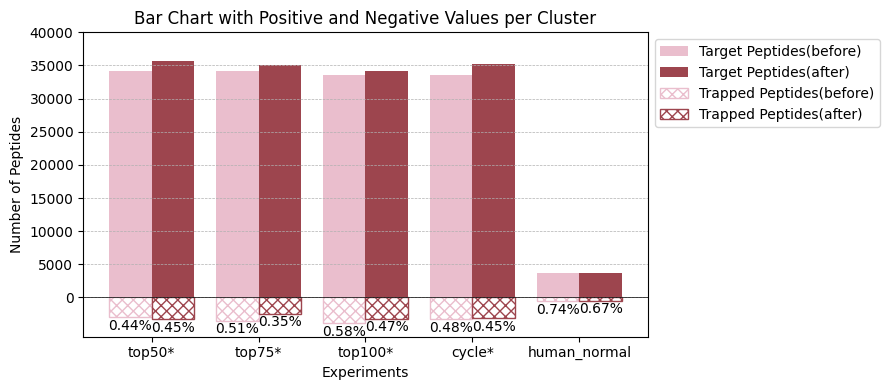

In [346]:
import numpy as np
import matplotlib.pyplot as plt

# 数据准备
clusters = 5  # 簇的数量
scaling_factor = 20
# 假设每个簇有两个柱子：一个正数柱子和一个负数柱子
before_positive_data = [34141, 34234, 33580, 33561, 3657]  # 正数数据
before_negative_data = np.array([149, 176, 196, 162, 27])*scaling_factor  # 负数数据
after_positive_data = [35610, 35043, 34175, 35168, 3740]  # 正数数据
after_negative_data = np.array([162, 121, 159, 158, 25])*scaling_factor  # 负数数据

# 柱子的宽度和位置
bar_width = 0.4  # 柱子的宽度
index = np.arange(clusters)  # X轴位置

# 创建一个图形和子图
fig, ax = plt.subplots(figsize=(9,4))

# 绘制正数柱子
ax.bar(index, before_positive_data, bar_width, label="Target Peptides(before)", color="#eabecd", align='center')
ax.bar(index+bar_width, after_positive_data, bar_width, label="Target Peptides(after)", color="#9d454e", align='center')
for i in range(5):
    ax.text(0+i, -before_negative_data[i]-1300, f"{before_negative_data[i]/before_positive_data[i]/scaling_factor*100:.2f}%", fontsize=10, ha='center', va='center')
# 绘制负数柱子
ax.bar(index, -before_negative_data, bar_width, label='Trapped Peptides(before)', color='white', align='center', hatch="xxx", edgecolor="#eabecd")
ax.bar(index+bar_width, -after_negative_data, bar_width, label="Trapped Peptides(after)", color='white', align='center', hatch="xxx", edgecolor="#9d454e")
for i in range(5):
    ax.text(0.4+i, -after_negative_data[i]-1300, f"{after_negative_data[i]/after_positive_data[i]/scaling_factor*100:.2f}%", fontsize=10, ha='center', va='center')

# 添加标签和标题
ax.set_xlabel('Experiments')
ax.set_ylabel('Number of Peptides')
ax.set_title('Bar Chart with Positive and Negative Values per Cluster')
ax.set_xticks(index+bar_width/2)
ax.set_yticks([0,5000,10000,15000,20000,25000,30000,35000,40000])
ax.set_xticklabels(["top50*","top75*","top100*","cycle*","human_normal"])
ax.legend(bbox_to_anchor=(1, 1), loc='upper left')  # 将图例放在图表外部以避免遮挡

# 设置y轴的零刻度线以突出显示
ax.axhline(y=0, color='black',linewidth=0.5)

# 添加网格线（可选）
ax.grid(axis='y', linestyle='--', linewidth=0.5)

# 显示图表
plt.tight_layout()
plt.show()

## 图8

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

[[[2462, 3593, 4472, 11373, 11763]], [[2657, 3785, 4664, 12035, 12607]], [[2738, 3762, 4925, 12158, 12483]], [[2578, 3735, 4667, 12258, 13165]]]


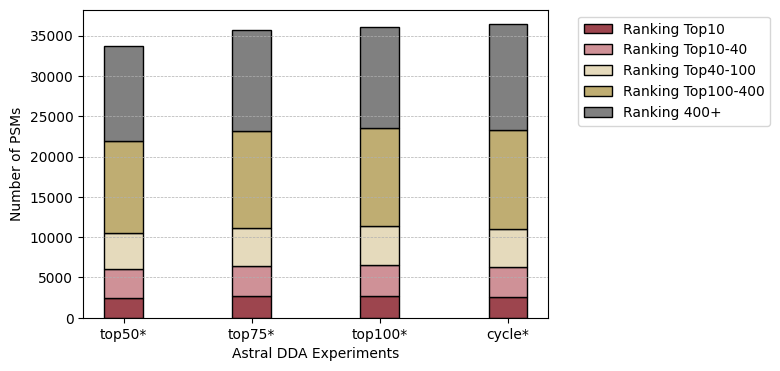

In [336]:
"""
图8: 修改粗打分前。selectpeak=5000，pepnum=100。四簇直方图，每簇一个柱子，分别为top10、top40、top100、top400的粗打分数目堆叠图
"""

# 数据准备
clusters = 4  # 簇的数量
stacks_per_cluster = 1  # 每个簇的堆叠柱子数量
sub_stacks = 5  # 每个柱子的内部堆叠数量（这里假设每个柱子都由3个不同颜色的部分组成）

# 示例数据：每个簇有3个柱子，每个柱子有3个堆叠部分
# data = np.random.randint(1, 10, size=(clusters, stacks_per_cluster, sub_stacks))
data = [[[2462,6055,10527,21900,33663]],[[2657,6442,11106,23141,35748]],
[[2738,6500,11425,23583,36066]],[[2578,6313,10980,23238,36403]]]
for ddd in data:
    for dd in ddd:
        for i in reversed(range(len(dd))):
            if i == 0:
                continue
            dd[i] = dd[i] - dd[i-1]


# 柱子的宽度和位置
bar_width = 0.3
index = np.arange(stacks_per_cluster)*bar_width  # X轴位置，对应每个簇中的柱子
cluster_positions = np.arange(clusters)  # 簇的位置，稍微间隔开


# 创建一个图形和子图
fig, ax = plt.subplots(figsize=(6,4))

# 颜色列表
colors = ["#9d454e","#cf9197","#e5dabc","#bfad72","grey"]
labels = ["Ranking Top10", "Ranking Top10-40", "Ranking Top40-100", "Ranking Top100-400", "Ranking 400+"]
print(data)

# 绘制每个簇的堆叠柱子
for cluster_idx, cluster_data in enumerate(data):
    bottom = np.zeros(stacks_per_cluster)  # 用于存储每个柱子的底部位置
    for stack_idx, stack_data in enumerate(cluster_data):
        # 绘制每个柱子的内部堆叠部分
        for sub_stack_idx, value in enumerate(stack_data):
            ax.bar(index[stack_idx] + cluster_positions[cluster_idx], value, bar_width, bottom=bottom[stack_idx],
                   label=labels[sub_stack_idx] if cluster_idx == 0 and stack_idx == 0 else None,
                   color=colors[sub_stack_idx], edgecolor="black")
            bottom[stack_idx] += value  # 更新底部位置以供下一个堆叠部分使用

# 添加标签和标题
ax.set_xlabel('Astral DDA Experiments')
ax.set_ylabel('Number of PSMs')
# ax.set_title('Stacked Bar Chart with 4 Clusters, 3 Stacks per Cluster, and 3 Sub-stacks per Stack')
ax.set_xticks(cluster_positions)  # 只设置第一个簇的X轴刻度位置作为示例
ax.set_xticklabels(["top50*","top75*","top100*","cycle*"])  # 设置X轴刻度标签
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')  # 将图例放在图表外部以避免遮挡
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', linewidth=0.5)

# 显示图表
# plt.tight_layout()
plt.show()

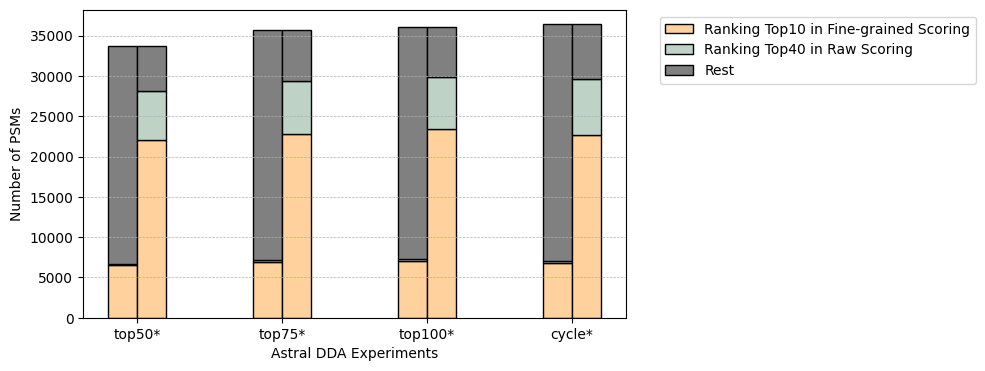

In [335]:
"""
图9: 修改粗打分后。selectpeak=5000，pepnum=100。四簇直方图，每簇两个柱子，分别为修改粗打分前后，粗打分进入top400+、top400、细打分进入top100的谱图数目堆叠图。 
"""

# 数据准备
clusters = 4  # 簇的数量
stacks_per_cluster = 2  # 每个簇的堆叠柱子数量
sub_stacks = 3  # 每个柱子的内部堆叠数量（这里假设每个柱子都由3个不同颜色的部分组成）

# 示例数据：每个簇有3个柱子，每个柱子有3个堆叠部分
data = [[[6512,6723,33663],[22036,28132,33663]],[[6952,7180,35748],[22745,29353,35748]],
[[7086,7273,36066],[23360,29817,36066]],[[6820,7068,36403],[22687,29593,36403]]]
for ddd in data:
    for dd in ddd:
        for i in reversed(range(len(dd))):
            if i == 0:
                continue
            dd[i] = dd[i] - dd[i-1]

# 柱子的宽度和位置
bar_width = 0.2
index = np.arange(stacks_per_cluster)*bar_width  # X轴位置，对应每个簇中的柱子
cluster_positions = np.arange(clusters)  # 簇的位置，稍微间隔开


# 创建一个图形和子图
fig, ax = plt.subplots(figsize=(7,4))

# 颜色列表
colors = ['#ffd19d', '#bed2c6', "grey"]
labels = ["Ranking Top10 in Fine-grained Scoring", "Ranking Top40 in Raw Scoring", "Rest"]

# 绘制每个簇的堆叠柱子
for cluster_idx, cluster_data in enumerate(data):
    bottom = np.zeros(stacks_per_cluster)  # 用于存储每个柱子的底部位置
    for stack_idx, stack_data in enumerate(cluster_data):
        # 绘制每个柱子的内部堆叠部分
        for sub_stack_idx, value in enumerate(stack_data):
            ax.bar(index[stack_idx] + cluster_positions[cluster_idx], value, bar_width, bottom=bottom[stack_idx],
                   label=labels[sub_stack_idx] if cluster_idx == 0 and stack_idx == 0 else None,
                   color=colors[sub_stack_idx], edgecolor="black")
            bottom[stack_idx] += value  # 更新底部位置以供下一个堆叠部分使用

# 添加标签和标题
ax.set_xlabel('Astral DDA Experiments')
ax.set_ylabel('Number of PSMs')
# ax.set_title('Stacked Bar Chart with 4 Clusters, 3 Stacks per Cluster, and 3 Sub-stacks per Stack')
ax.set_xticks(cluster_positions+index[1]/2)  # 只设置第一个簇的X轴刻度位置作为示例
ax.set_xticklabels(["top50*","top75*","top100*","cycle*"])  # 设置X轴刻度标签
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')  # 将图例放在图表外部以避免遮挡
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', linewidth=0.5)

# 显示图表
# plt.tight_layout()
plt.show()

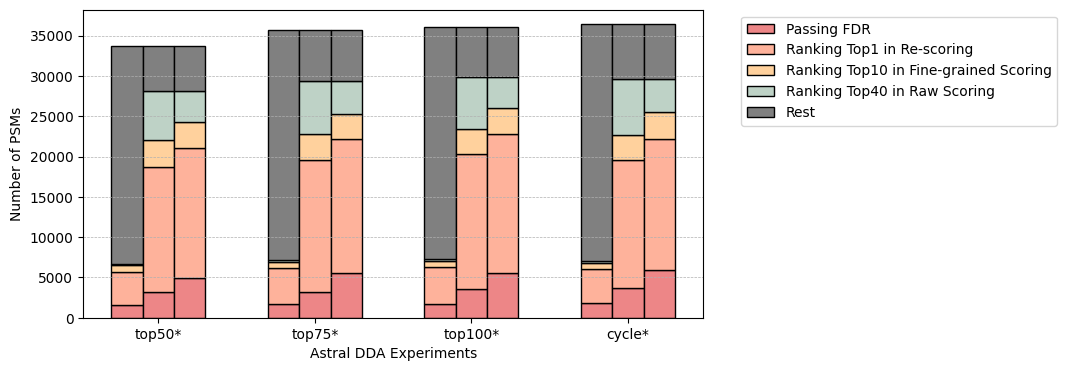

In [333]:
"""
图10: 修改细打分后selectpeak=5000，pepnum=10。
四簇直方图，每簇三个柱子，分别为修改粗打分前、修改粗打分后、修改细打分后，
粗打分进入top40、细打分进入top10、重打分排名为top1、通过FDR阈值的谱图数目堆叠图。
"""

# 数据准备
clusters = 4  # 簇的数量
stacks_per_cluster = 5  # 每个簇的堆叠柱子数量
sub_stacks = 3  # 每个柱子的内部堆叠数量（这里假设每个柱子都由3个不同颜色的部分组成）

# 示例数据：每个簇有3个柱子，每个柱子有3个堆叠部分
data = [[[1533,5704,6512,6723,33663],[3215,18736,22036,28132,33663],[4991,21113,24340,28132,33663]],
        [[1713,6149,6952,7180,35748],[3187,19629,22745,29353,35748],[5609,22194,25328,29353,35748]],
        [[1692,6303,7086,7273,36066],[3590,20290,23360,29817,36066],[5589,22805,25978,29817,36066]],
        [[1815,6012,6820,7068,36403],[3643,19554,22687,29593,36403],[5936,22224,25482,29593,36403]]]
for ddd in data:
    for dd in ddd:
        for i in reversed(range(len(dd))):
            if i == 0:
                continue
            dd[i] = dd[i] - dd[i-1]
            
# 柱子的宽度和位置
bar_width = 0.2
index = np.arange(stacks_per_cluster)*bar_width  # X轴位置，对应每个簇中的柱子
cluster_positions = np.arange(clusters)  # 簇的位置，稍微间隔开


# 创建一个图形和子图
fig, ax = plt.subplots(figsize=(8,4))

# 颜色列表
colors = ["#ed8687", "#feb29b", '#ffd19d', '#bed2c6', "grey"]
labels = ["Passing FDR", "Ranking Top1 in Re-scoring", "Ranking Top10 in Fine-grained Scoring", "Ranking Top40 in Raw Scoring", "Rest"]

# 绘制每个簇的堆叠柱子
for cluster_idx, cluster_data in enumerate(data):
    bottom = np.zeros(stacks_per_cluster)  # 用于存储每个柱子的底部位置
    for stack_idx, stack_data in enumerate(cluster_data):
        # 绘制每个柱子的内部堆叠部分
        for sub_stack_idx, value in enumerate(stack_data):
            ax.bar(index[stack_idx] + cluster_positions[cluster_idx], value, bar_width, bottom=bottom[stack_idx],
                   label=labels[sub_stack_idx] if cluster_idx == 0 and stack_idx == 0 else None,
                   color=colors[sub_stack_idx], edgecolor="black")
            bottom[stack_idx] += value  # 更新底部位置以供下一个堆叠部分使用

# 添加标签和标题
ax.set_xlabel('Astral DDA Experiments')
ax.set_ylabel('Number of PSMs')
# ax.set_title('Stacked Bar Chart with 4 Clusters, 3 Stacks per Cluster, and 3 Sub-stacks per Stack')
ax.set_xticks(cluster_positions+index[1])  # 只设置第一个簇的X轴刻度位置作为示例
ax.set_xticklabels(["top50*","top75*","top100*","cycle*"])  # 设置X轴刻度标签
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')  # 将图例放在图表外部以避免遮挡
# ax.legend(title='Cluster and Stack Info', loc='upper right')  # 将图例放在图表外部以避免遮挡
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', linewidth=0.5)

# 显示图表
# plt.tight_layout()
plt.show()

In [ ]:
# 图4

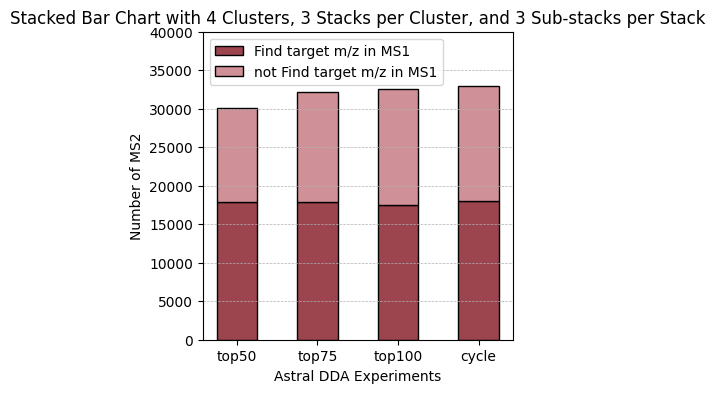

In [332]:
"""
图10: 修改细打分后selectpeak=5000，pepnum=10。
四簇直方图，每簇三个柱子，分别为修改粗打分前、修改粗打分后、修改细打分后，
粗打分进入top40、细打分进入top10、重打分排名为top1、通过FDR阈值的谱图数目堆叠图。
"""

# 数据准备
clusters = 4  # 簇的数量
stacks_per_cluster = 1  # 每个簇的堆叠柱子数量
sub_stacks = 2  # 每个柱子的内部堆叠数量（这里假设每个柱子都由3个不同颜色的部分组成）

# 示例数据：每个簇有3个柱子，每个柱子有3个堆叠部分
data = [[[17844,30147]],
        [[17882,32177]],
        [[17509,32617]],
        [[17952,32912]]]
for ddd in data:
    for dd in ddd:
        for i in reversed(range(len(dd))):
            if i == 0:
                continue
            dd[i] = dd[i] - dd[i-1]
            
# 柱子的宽度和位置
bar_width = 0.5
index = np.arange(stacks_per_cluster)*bar_width  # X轴位置，对应每个簇中的柱子
cluster_positions = np.arange(clusters)  # 簇的位置，稍微间隔开


# 创建一个图形和子图
fig, ax = plt.subplots(figsize=(4,4))

# 颜色列表
colors = ["#9d454e", "#cf9197", "#bfad72", "#e5dabc",]
labels = ["Find target m/z in MS1", "not Find target m/z in MS1"]

# 绘制每个簇的堆叠柱子
for cluster_idx, cluster_data in enumerate(data):
    bottom = np.zeros(stacks_per_cluster)  # 用于存储每个柱子的底部位置
    for stack_idx, stack_data in enumerate(cluster_data):
        # 绘制每个柱子的内部堆叠部分
        for sub_stack_idx, value in enumerate(stack_data):
            ax.bar(index[stack_idx] + cluster_positions[cluster_idx], value, bar_width, bottom=bottom[stack_idx],
                   label=labels[sub_stack_idx] if cluster_idx == 0 and stack_idx == 0 else None,
                   color=colors[sub_stack_idx], edgecolor="black")
            bottom[stack_idx] += value  # 更新底部位置以供下一个堆叠部分使用

# 添加标签和标题
ax.set_xlabel('Astral DDA Experiments')
ax.set_ylabel('Number of MS2')
ax.set_ylim([0,40000])
ax.set_title('Stacked Bar Chart with 4 Clusters, 3 Stacks per Cluster, and 3 Sub-stacks per Stack')
ax.set_xticks(cluster_positions)  # 只设置第一个簇的X轴刻度位置作为示例
ax.set_xticklabels(["top50","top75","top100","cycle"])  # 设置X轴刻度标签
ax.legend(loc='upper left')  # 将图例放在图表外部以避免遮挡
# ax.legend(title='Cluster and Stack Info', loc='upper right')  # 将图例放在图表外部以避免遮挡
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', linewidth=0.5)

# 显示图表
# plt.tight_layout()
plt.show()

## 分割线

In [ ]:
"""
两配色(ori,ori+open)：["#c0cffa","#7d8ec4","#6171a9","#334173","#212c58"]
三配色(MSFragger,MSFragger+DL,MSFragger+open)：["#ffd9e8","#de95ba","#7f4a88"],["#d6ddac","#bcc681","#a4ae5c","#757f24","#5e6710"]
六配色(new,new+open,new+dl,new+open+dl)：["#b3a3ba","#8d769a","#68507b","#46315c","28193d"]

# colors = ["#eabecd", "#9d454e", "#ffd19d", "#9897BC", "#C8B8D4"]
"""

C:\Users\dell\AppData\Local\Temp\ipykernel_84868\2188430632.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Astral DDA Hela"])


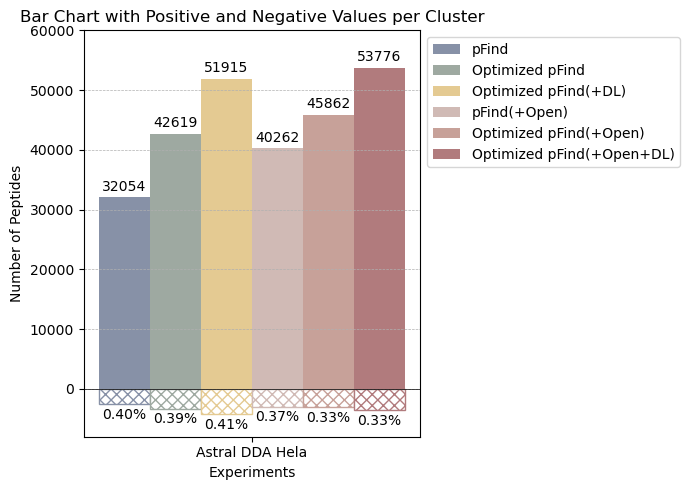

In [195]:
import numpy as np
import matplotlib.pyplot as plt

# [ori,new,new-dl,ori-open,new-open,new-open-dl]

# 柱子的宽度和位置
bar_width = 0.6  # 柱子的宽度
index = np.arange(clusters)  # X轴位置

# 创建一个图形和子图
fig, ax = plt.subplots(figsize=(7,5))

# 数据准备: 假设每个簇有两个柱子：一个正数柱子和一个负数柱子
scaling_factor = 20
# Astral
ax.set_ylim(-8000,60000)
ax.set_xticklabels(["Astral DDA Hela"])
positive_datas = np.array([[32054,42619,51915,40262,45862,53776]])  # clusters*bars
negative_datas = np.array([[129,165,213,148,152,178]])*scaling_factor
diff=1800
# # Gygi
# ax.set_ylim(-35000,280000)
# ax.set_xticklabels(["Gygi-Human-QF"])
# positive_datas = np.array([[169048,175501,190493,244994,249316,264664]])  # clusters*bars
# negative_datas = np.array([[785,823,907,969,752,853]])*scaling_factor
# diff=7000
# # HLA
# ax.set_ylim(0,30000)
# ax.set_xticklabels(["HLA"])
# positive_datas = np.array([[16420,20688,26467,19622,20876,27156]])  # clusters*bars
# negative_datas = np.array([[50,50,50,50]])*scaling_factor
# diff = 900
# # Human-gut
# ax.set_ylim(0,155000)
# ax.set_xticklabels(["Human-gut"])
# positive_datas = np.array([[91184,106626,130844,117995,132917,145474]])  # clusters*bars
# negative_datas = np.array([[50,50,50,50]])*scaling_factor
# diff=3000

positive_labels = ["pFind", "Optimized pFind", "Optimized pFind(+DL)",
                   "pFind(+Open)", "Optimized pFind(+Open)","Optimized pFind(+Open+DL)"]
colors = ["#8791a7","#9EA9A1","#E4CA92","#D0BAB5","#C7A199","#B17B7D"]


# positive_labels = ["Peptides(pFind3)", "Peptides(modified pFind3)", "Peptides(modified pFind3 + DL)",
#                    "Peptides(MSFragger)","Peptides(MSFragger+MSBooster)"]
# negative_labels = ["Trapped Peptides(pFind3)", "Trapped Peptides(modified pFind3)", "Trapped Peptides(modified pFind3 + DL)",
#                   "Trapped Peptides(MSFragger)", "Trapped Peptides(MSFragger+MSBooster)"]
# positive_labels = ["Peptides(pFind3)", "Peptides(modified pFind3)", "Peptides(modified pFind3 + DL)",
#                    "Peptides(modified pFind3 + RT)","modified pFind3 + MS2"]
# negative_labels = ["Trapped Peptides(pFind3)", "Trapped Peptides(modified pFind3)", "Trapped Peptides(modified pFind3 + DL)",
#                   "Trapped Peptides(modified pFind3 + RT)", "Trapped Peptides(modified pFind3 + MS2)"]


clusters = positive_datas.shape[0]  # 簇的数量
bars = positive_datas.shape[1]      # 每簇柱子数量
colors = colors[:bars]
positive_labels = positive_labels[:bars]
negative_labels = negative_labels[:bars]



# 绘制正数柱子
for bar_idx,(color,label) in enumerate(zip(colors,positive_labels)):
    ax.bar(index+bar_width*bar_idx, positive_datas[:,bar_idx], bar_width, label=positive_labels[bar_idx], color=color, align='center')
    for cluster_idx in range(clusters):
        ax.text(index[cluster_idx]+bar_idx*bar_width, positive_datas[cluster_idx,bar_idx]+diff, f"{positive_datas[cluster_idx,bar_idx]}", fontsize=10, ha='center', va='center')
# 绘制负数柱子
for bar_idx,color in enumerate(colors):
    ax.bar(index+bar_width*bar_idx, -negative_datas[:,bar_idx], bar_width, color='white', align='center', hatch="xxx", edgecolor=color)
    for cluster_idx in range(clusters):
        ax.text(index[cluster_idx]+bar_idx*bar_width, -negative_datas[cluster_idx,bar_idx]-diff, f"{negative_datas[cluster_idx,bar_idx]/positive_datas[cluster_idx,bar_idx]/scaling_factor*100:.2f}%", fontsize=10, ha='center', va='center')

# 添加标签和标题
ax.set_xlabel('Experiments')
ax.set_ylabel('Number of Peptides')
ax.set_title('Bar Chart with Positive and Negative Values per Cluster')
ax.set_xticks(index+bar_width*2.5)

# ax.set_xticklabels(["Astral DDA top50"])
ax.legend(bbox_to_anchor=(1, 1), loc='upper left')  # 将图例放在图表外部以避免遮挡

# 设置y轴的零刻度线以突出显示
ax.axhline(y=0, color='black',linewidth=0.5)

# 添加网格线（可选）
ax.grid(axis='y', linestyle='--', linewidth=0.5)

# 显示图表
plt.tight_layout()
plt.show()

C:\Users\dell\AppData\Local\Temp\ipykernel_84868\2457666360.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Astral DDA Hela"])


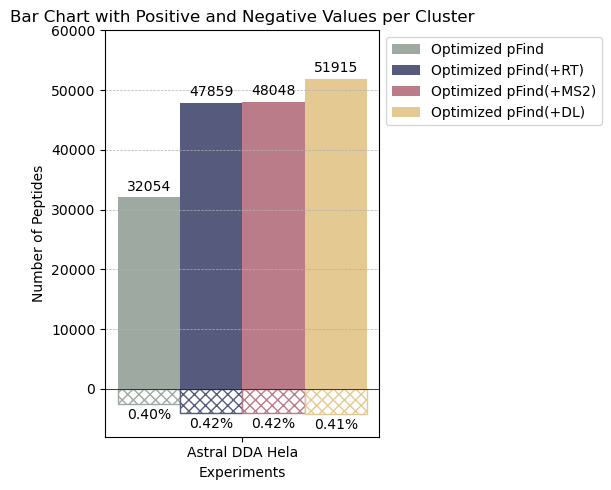

In [183]:
import numpy as np
import matplotlib.pyplot as plt

# [new,new-rt,new-ms2,new-dl]

# 柱子的宽度和位置
bar_width = 0.6  # 柱子的宽度
index = np.arange(clusters)  # X轴位置

# 创建一个图形和子图
fig, ax = plt.subplots(figsize=(6,5))

# 数据准备: 假设每个簇有两个柱子：一个正数柱子和一个负数柱子
scaling_factor = 20
# Astral
ax.set_ylim(-8000,60000)
ax.set_xticklabels(["Astral DDA Hela"])
positive_datas = np.array([[32054,47859,48048,51915]])  # clusters*bars
negative_datas = np.array([[129,202,200,213]])*scaling_factor
diff=1800
# # Gygi
# ax.set_ylim(-30000,210000)
# ax.set_xticklabels(["Gygi-Human-QF"])
# positive_datas = np.array([[169048,182509,184939,190493]])  # clusters*bars
# negative_datas = np.array([[785,770,889,907]])*scaling_factor
# diff=6000
# # HLA
# ax.set_ylim(0,30000)
# ax.set_xticklabels(["HLA"])
# positive_datas = np.array([[16420,22500,25299,26467]])  # clusters*bars
# negative_datas = np.array([[50,50,50,50]])*scaling_factor
# diff = 900

positive_labels = ["Optimized pFind", "Optimized pFind(+RT)", "Optimized pFind(+MS2)", "Optimized pFind(+DL)"]
colors = ["#9EA9A1","#565A7D","#BA7C89","#E4CA92"]


# positive_labels = ["Peptides(pFind3)", "Peptides(modified pFind3)", "Peptides(modified pFind3 + DL)",
#                    "Peptides(MSFragger)","Peptides(MSFragger+MSBooster)"]
# negative_labels = ["Trapped Peptides(pFind3)", "Trapped Peptides(modified pFind3)", "Trapped Peptides(modified pFind3 + DL)",
#                   "Trapped Peptides(MSFragger)", "Trapped Peptides(MSFragger+MSBooster)"]
# positive_labels = ["Peptides(pFind3)", "Peptides(modified pFind3)", "Peptides(modified pFind3 + DL)",
#                    "Peptides(modified pFind3 + RT)","modified pFind3 + MS2"]
# negative_labels = ["Trapped Peptides(pFind3)", "Trapped Peptides(modified pFind3)", "Trapped Peptides(modified pFind3 + DL)",
#                   "Trapped Peptides(modified pFind3 + RT)", "Trapped Peptides(modified pFind3 + MS2)"]


clusters = positive_datas.shape[0]  # 簇的数量
bars = positive_datas.shape[1]      # 每簇柱子数量
colors = colors[:bars]
positive_labels = positive_labels[:bars]
negative_labels = negative_labels[:bars]



# 绘制正数柱子
for bar_idx,(color,label) in enumerate(zip(colors,positive_labels)):
    ax.bar(index+bar_width*bar_idx, positive_datas[:,bar_idx], bar_width, label=positive_labels[bar_idx], color=color, align='center')
    for cluster_idx in range(clusters):
        ax.text(index[cluster_idx]+bar_idx*bar_width, positive_datas[cluster_idx,bar_idx]+diff, f"{positive_datas[cluster_idx,bar_idx]}", fontsize=10, ha='center', va='center')
# 绘制负数柱子
for bar_idx,color in enumerate(colors):
    ax.bar(index+bar_width*bar_idx, -negative_datas[:,bar_idx], bar_width, color='white', align='center', hatch="xxx", edgecolor=color)
    for cluster_idx in range(clusters):
        ax.text(index[cluster_idx]+bar_idx*bar_width, -negative_datas[cluster_idx,bar_idx]-diff, f"{negative_datas[cluster_idx,bar_idx]/positive_datas[cluster_idx,bar_idx]/scaling_factor*100:.2f}%", fontsize=10, ha='center', va='center')

# 添加标签和标题
ax.set_xlabel('Experiments')
ax.set_ylabel('Number of Peptides')
ax.set_title('Bar Chart with Positive and Negative Values per Cluster')
ax.set_xticks(index+bar_width*1.5)

# ax.set_xticklabels(["Astral DDA top50"])
ax.legend(bbox_to_anchor=(1, 1), loc='upper left')  # 将图例放在图表外部以避免遮挡

# 设置y轴的零刻度线以突出显示
ax.axhline(y=0, color='black',linewidth=0.5)

# 添加网格线（可选）
ax.grid(axis='y', linestyle='--', linewidth=0.5)

# 显示图表
plt.tight_layout()
plt.show()

C:\Users\dell\AppData\Local\Temp\ipykernel_84868\3300313334.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Human-gut"])


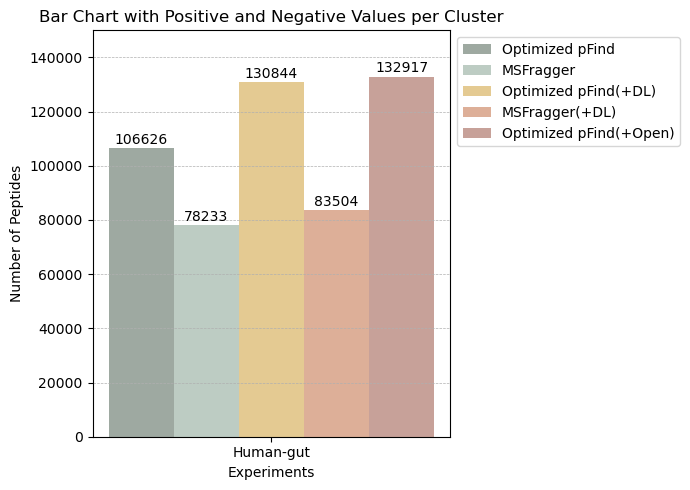

In [217]:
import numpy as np
import matplotlib.pyplot as plt

# [new,msfragger,new-open,msfragger-open,new-dl,msfragger-dl]

# 柱子的宽度和位置
bar_width = 0.6  # 柱子的宽度
index = np.arange(clusters)  # X轴位置

# 创建一个图形和子图
fig, ax = plt.subplots(figsize=(7,5))

# 数据准备: 假设每个簇有两个柱子：一个正数柱子和一个负数柱子
scaling_factor = 20
# # Astral
# ax.set_ylim(-8000,60000)
# ax.set_xticklabels(["Astral DDA Hela"])
# positive_datas = np.array([[42619,34050,51915,40969,45862,33012]])  # clusters*bars
# negative_datas = np.array([[165,150,213,176,152,83]])*scaling_factor
# diff=1800
# # Gygi
# ax.set_ylim(-35000,280000)
# ax.set_xticklabels(["Gygi-Human-QF"])
# positive_datas = np.array([[175501,131944,190493,138720,249316,144135]])  # clusters*bars
# negative_datas = np.array([[823,629,907,671,752,206]])*scaling_factor
# diff=7000
# # HLA
# ax.set_ylim(0,30000)
# ax.set_xticklabels(["HLA"])
# positive_datas = np.array([[20688,17428,26467,19119,20876]])  # clusters*bars
# negative_datas = np.array([[50,50,50,50]])*scaling_factor
# diff = 900
# Human-gut
ax.set_ylim(0,150000)
ax.set_xticklabels(["Human-gut"])
positive_datas = np.array([[106626,78233,130844,83504,132917]])  # clusters*bars
negative_datas = np.array([[50,50,50,50]])*scaling_factor
diff=3000

positive_labels = ["Optimized pFind", "MSFragger", "Optimized pFind(+DL)",
                   "MSFragger(+DL)", "Optimized pFind(+Open)","MSFragger(+Open)"]
colors = ["#9EA9A1","#BDCCC3","#E4CA92","#DDAF98","#C7A199","#966360"]


# positive_labels = ["Peptides(pFind3)", "Peptides(modified pFind3)", "Peptides(modified pFind3 + DL)",
#                    "Peptides(MSFragger)","Peptides(MSFragger+MSBooster)"]
# negative_labels = ["Trapped Peptides(pFind3)", "Trapped Peptides(modified pFind3)", "Trapped Peptides(modified pFind3 + DL)",
#                   "Trapped Peptides(MSFragger)", "Trapped Peptides(MSFragger+MSBooster)"]
# positive_labels = ["Peptides(pFind3)", "Peptides(modified pFind3)", "Peptides(modified pFind3 + DL)",
#                    "Peptides(modified pFind3 + RT)","modified pFind3 + MS2"]
# negative_labels = ["Trapped Peptides(pFind3)", "Trapped Peptides(modified pFind3)", "Trapped Peptides(modified pFind3 + DL)",
#                   "Trapped Peptides(modified pFind3 + RT)", "Trapped Peptides(modified pFind3 + MS2)"]


clusters = positive_datas.shape[0]  # 簇的数量
bars = positive_datas.shape[1]      # 每簇柱子数量
colors = colors[:bars]
positive_labels = positive_labels[:bars]
negative_labels = negative_labels[:bars]



# 绘制正数柱子
for bar_idx,(color,label) in enumerate(zip(colors,positive_labels)):
    ax.bar(index+bar_width*bar_idx, positive_datas[:,bar_idx], bar_width, label=positive_labels[bar_idx], color=color, align='center')
    for cluster_idx in range(clusters):
        ax.text(index[cluster_idx]+bar_idx*bar_width, positive_datas[cluster_idx,bar_idx]+diff, f"{positive_datas[cluster_idx,bar_idx]}", fontsize=10, ha='center', va='center')
# # 绘制负数柱子
# for bar_idx,color in enumerate(colors):
#     ax.bar(index+bar_width*bar_idx, -negative_datas[:,bar_idx], bar_width, color='white', align='center', hatch="xxx", edgecolor=color)
#     for cluster_idx in range(clusters):
#         ax.text(index[cluster_idx]+bar_idx*bar_width, -negative_datas[cluster_idx,bar_idx]-diff, f"{negative_datas[cluster_idx,bar_idx]/positive_datas[cluster_idx,bar_idx]/scaling_factor*100:.2f}%", fontsize=10, ha='center', va='center')

# 添加标签和标题
ax.set_xlabel('Experiments')
ax.set_ylabel('Number of Peptides')
ax.set_title('Bar Chart with Positive and Negative Values per Cluster')
ax.set_xticks(index+bar_width*2)

# ax.set_xticklabels(["Astral DDA top50"])
ax.legend(bbox_to_anchor=(1, 1), loc='upper left')  # 将图例放在图表外部以避免遮挡

# 设置y轴的零刻度线以突出显示
ax.axhline(y=0, color='black',linewidth=0.5)

# 添加网格线（可选）
ax.grid(axis='y', linestyle='--', linewidth=0.5)

# 显示图表
plt.tight_layout()
plt.show()

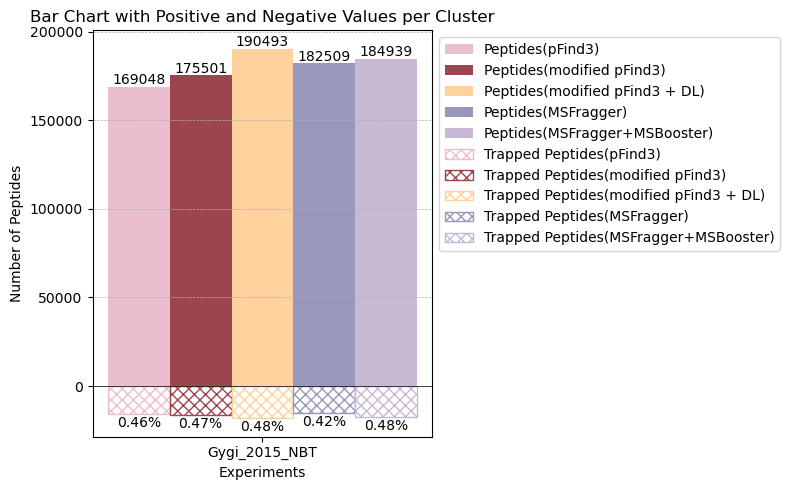

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# 数据准备
scaling_factor = 20
# 假设每个簇有两个柱子：一个正数柱子和一个负数柱子
positive_datas = np.array([[169048, 175501, 190493, 182509, 184939]])  # clusters*bars
negative_datas = np.array([[785, 823, 907, 770, 889]])*scaling_factor
colors = ["#eabecd", "#9d454e", "#ffd19d", "#9897BC", "#C8B8D4"]
# positive_labels = ["Peptides(pFind3)", "Peptides(modified pFind3)", "Peptides(modified pFind3 + DL)",
#                    "Peptides(MSFragger)","Peptides(MSFragger+MSBooster)"]
# negative_labels = ["Trapped Peptides(pFind3)", "Trapped Peptides(modified pFind3)", "Trapped Peptides(modified pFind3 + DL)",
#                   "Trapped Peptides(MSFragger)", "Trapped Peptides(MSFragger+MSBooster)"]
positive_labels = ["Peptides(pFind3)", "Peptides(modified pFind3)", "Peptides(modified pFind3 + DL)",
                   "Peptides(modified pFind3 + RT)","modified pFind3 + MS2"]
negative_labels = ["Trapped Peptides(pFind3)", "Trapped Peptides(modified pFind3)", "Trapped Peptides(modified pFind3 + DL)",
                  "Trapped Peptides(modified pFind3 + RT)", "Trapped Peptides(modified pFind3 + MS2)"]

clusters = positive_datas.shape[0]  # 簇的数量
bars = positive_datas.shape[1]      # 每簇柱子数量
colors = colors[:bars]
positive_labels = positive_labels[:bars]
negative_labels = negative_labels[:bars]

# 柱子的宽度和位置
bar_width = 0.4  # 柱子的宽度
index = np.arange(clusters)  # X轴位置

# 创建一个图形和子图
fig, ax = plt.subplots(figsize=(8,5))

# 绘制正数柱子
for bar_idx,(color,label) in enumerate(zip(colors,positive_labels)):
    ax.bar(index+bar_width*bar_idx, positive_datas[:,bar_idx], bar_width, label=positive_labels[bar_idx], color=color, align='center')
    for cluster_idx in range(clusters):
        ax.text(index[cluster_idx]+bar_idx*bar_width, positive_datas[cluster_idx,bar_idx]+3600, f"{positive_datas[cluster_idx,bar_idx]}", fontsize=10, ha='center', va='center')
# 绘制负数柱子
for bar_idx,(color,label) in enumerate(zip(colors,negative_labels)):
    ax.bar(index+bar_width*bar_idx, -negative_datas[:,bar_idx], bar_width, label=negative_labels[bar_idx], color='white', align='center', hatch="xxx", edgecolor=color)
    for cluster_idx in range(clusters):
        ax.text(index[cluster_idx]+bar_idx*bar_width, -negative_datas[cluster_idx,bar_idx]-5000, f"{negative_datas[cluster_idx,bar_idx]/positive_datas[cluster_idx,bar_idx]/scaling_factor*100:.2f}%", fontsize=10, ha='center', va='center')

# 添加标签和标题
ax.set_xlabel('Experiments')
ax.set_ylabel('Number of Peptides')
ax.set_title('Bar Chart with Positive and Negative Values per Cluster')
ax.set_xticks(index+bar_width*2)
# ax.set_ylim(-8000,55000)
# ax.set_yticks([0,5000,10000,15000,20000,25000,30000,35000,40000])
ax.set_xticklabels(["Gygi_2015_NBT"])
ax.legend(bbox_to_anchor=(1, 1), loc='upper left')  # 将图例放在图表外部以避免遮挡

# 设置y轴的零刻度线以突出显示
ax.axhline(y=0, color='black',linewidth=0.5)

# 添加网格线（可选）
ax.grid(axis='y', linestyle='--', linewidth=0.5)

# 显示图表
plt.tight_layout()
plt.show()

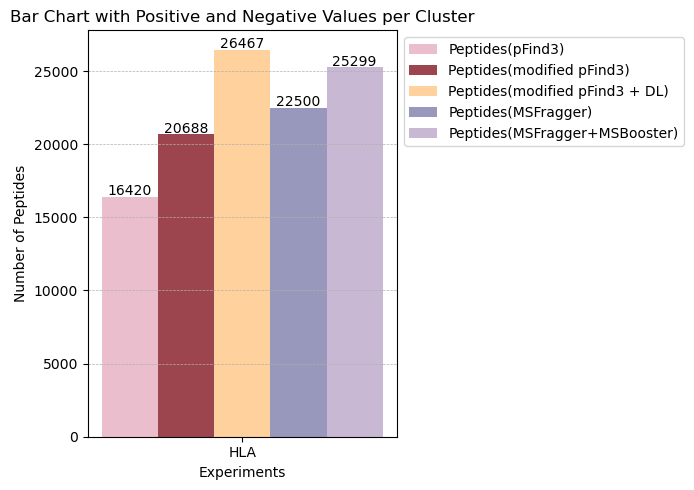

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# 数据准备
scaling_factor = 20
# 假设每个簇有两个柱子：一个正数柱子和一个负数柱子
positive_datas = np.array([[16420, 20688, 26467, 22500, 25299]])  # clusters*bars
negative_datas = np.array([[50, 50, 50, 50]])*scaling_factor
colors = ["#eabecd", "#9d454e", "#ffd19d", "#9897BC", "#C8B8D4"]
# positive_labels = ["Peptides(pFind3)", "Peptides(modified pFind3)", "Peptides(modified pFind3 + DL)",
#                    "Peptides(MSFragger)","Peptides(MSFragger+MSBooster)"]
# negative_labels = ["Trapped Peptides(pFind3)", "Trapped Peptides(modified pFind3)", "Trapped Peptides(modified pFind3 + DL)",
#                   "Trapped Peptides(MSFragger)", "Trapped Peptides(MSFragger+MSBooster)"]
positive_labels = ["Peptides(pFind3)", "Peptides(modified pFind3)", "Peptides(modified pFind3 + DL)",
                   "Peptides(MSFragger)","Peptides(MSFragger+MSBooster)"]
negative_labels = ["Trapped Peptides(pFind3)", "Trapped Peptides(modified pFind3)", "Trapped Peptides(modified pFind3 + DL)",
                  "Trapped Peptides(MSFragger)", "Trapped Peptides(MSFragger+MSBooster)"]

clusters = positive_datas.shape[0]  # 簇的数量
bars = positive_datas.shape[1]      # 每簇柱子数量
colors = colors[:bars]
positive_labels = positive_labels[:bars]
negative_labels = negative_labels[:bars]

# 柱子的宽度和位置
bar_width = 0.4  # 柱子的宽度
index = np.arange(clusters)  # X轴位置

# 创建一个图形和子图
fig, ax = plt.subplots(figsize=(7,5))

# 绘制正数柱子
for bar_idx,(color,label) in enumerate(zip(colors,positive_labels)):
    ax.bar(index+bar_width*bar_idx, positive_datas[:,bar_idx], bar_width, label=positive_labels[bar_idx], color=color, align='center')
    for cluster_idx in range(clusters):
        ax.text(index[cluster_idx]+bar_idx*bar_width, positive_datas[cluster_idx,bar_idx]+360, f"{positive_datas[cluster_idx,bar_idx]}", fontsize=10, ha='center', va='center')
# # 绘制负数柱子
# for bar_idx,(color,label) in enumerate(zip(colors,negative_labels)):
#     ax.bar(index+bar_width*bar_idx, -negative_datas[:,bar_idx], bar_width, label=negative_labels[bar_idx], color='white', align='center', hatch="xxx", edgecolor='white')
#     # for cluster_idx in range(clusters):
#     #     ax.text(index[cluster_idx]+bar_idx*bar_width, -negative_datas[cluster_idx,bar_idx]-5000, f"{negative_datas[cluster_idx,bar_idx]/positive_datas[cluster_idx,bar_idx]/scaling_factor*100:.2f}%", fontsize=10, ha='center', va='center')

# 添加标签和标题
ax.set_xlabel('Experiments')
ax.set_ylabel('Number of Peptides')
ax.set_title('Bar Chart with Positive and Negative Values per Cluster')
ax.set_xticks(index+bar_width*2)
# ax.set_ylim(-8000,55000)
# ax.set_yticks([0,5000,10000,15000,20000,25000,30000,35000,40000])
ax.set_xticklabels(["HLA"])
ax.legend(bbox_to_anchor=(1, 1), loc='upper left')  # 将图例放在图表外部以避免遮挡

# 设置y轴的零刻度线以突出显示
ax.axhline(y=0, color='black',linewidth=0.5)

# 添加网格线（可选）
ax.grid(axis='y', linestyle='--', linewidth=0.5)

# 显示图表
plt.tight_layout()
plt.show()

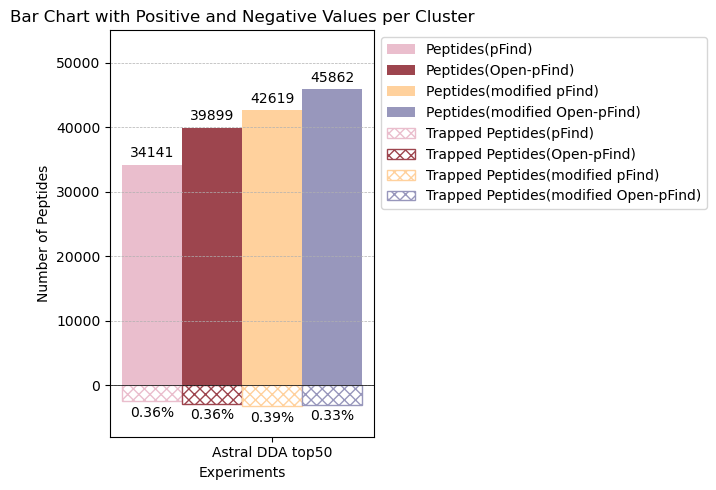

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# 数据准备
scaling_factor = 20
# 假设每个簇有两个柱子：一个正数柱子和一个负数柱子
positive_datas = np.array([[34141, 39899, 42619, 45862]])  # clusters*bars
negative_datas = np.array([[124, 145, 165, 152]])*scaling_factor
colors = ["#eabecd", "#9d454e", "#ffd19d", "#9897BC", "#C8B8D4"]
# positive_labels = ["Peptides(pFind3)", "Peptides(modified pFind3)", "Peptides(modified pFind3 + DL)",
#                    "Peptides(MSFragger)","Peptides(MSFragger+MSBooster)"]
# negative_labels = ["Trapped Peptides(pFind3)", "Trapped Peptides(modified pFind3)", "Trapped Peptides(modified pFind3 + DL)",
#                   "Trapped Peptides(MSFragger)", "Trapped Peptides(MSFragger+MSBooster)"]
positive_labels = ["Peptides(pFind)", "Peptides(Open-pFind)","Peptides(modified pFind)", "Peptides(modified Open-pFind)"]
negative_labels = ["Trapped Peptides(pFind)", "Trapped Peptides(Open-pFind)", "Trapped Peptides(modified pFind)",
                  "Trapped Peptides(modified Open-pFind)"]

clusters = positive_datas.shape[0]  # 簇的数量
bars = positive_datas.shape[1]      # 每簇柱子数量
colors = colors[:bars]
positive_labels = positive_labels[:bars]
negative_labels = negative_labels[:bars]

# 柱子的宽度和位置
bar_width = 0.4  # 柱子的宽度
index = np.arange(clusters)  # X轴位置

# 创建一个图形和子图
fig, ax = plt.subplots(figsize=(7,5))

# 绘制正数柱子
for bar_idx,(color,label) in enumerate(zip(colors,positive_labels)):
    ax.bar(index+bar_width*bar_idx, positive_datas[:,bar_idx], bar_width, label=positive_labels[bar_idx], color=color, align='center')
    for cluster_idx in range(clusters):
        ax.text(index[cluster_idx]+bar_idx*bar_width, positive_datas[cluster_idx,bar_idx]+1800, f"{positive_datas[cluster_idx,bar_idx]}", fontsize=10, ha='center', va='center')
# 绘制负数柱子
for bar_idx,(color,label) in enumerate(zip(colors,negative_labels)):
    ax.bar(index+bar_width*bar_idx, -negative_datas[:,bar_idx], bar_width, label=negative_labels[bar_idx], color='white', align='center', hatch="xxx", edgecolor=color)
    for cluster_idx in range(clusters):
        ax.text(index[cluster_idx]+bar_idx*bar_width, -negative_datas[cluster_idx,bar_idx]-1800, f"{negative_datas[cluster_idx,bar_idx]/positive_datas[cluster_idx,bar_idx]/scaling_factor*100:.2f}%", fontsize=10, ha='center', va='center')

# 添加标签和标题
ax.set_xlabel('Experiments')
ax.set_ylabel('Number of Peptides')
ax.set_title('Bar Chart with Positive and Negative Values per Cluster')
ax.set_xticks(index+bar_width*2)
ax.set_ylim(-8000,55000)
# ax.set_yticks([0,5000,10000,15000,20000,25000,30000,35000,40000])
ax.set_xticklabels(["Astral DDA top50"])
ax.legend(bbox_to_anchor=(1, 1), loc='upper left')  # 将图例放在图表外部以避免遮挡

# 设置y轴的零刻度线以突出显示
ax.axhline(y=0, color='black',linewidth=0.5)

# 添加网格线（可选）
ax.grid(axis='y', linestyle='--', linewidth=0.5)

# 显示图表
plt.tight_layout()
plt.show()

C:\Users\dell\AppData\Local\Temp\ipykernel_21384\434370288.py:56: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


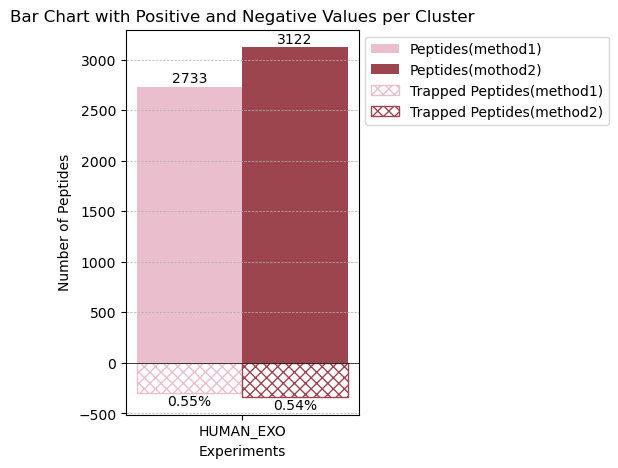

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# 数据准备
scaling_factor = 20
# 假设每个簇有两个柱子：一个正数柱子和一个负数柱子
# positive_datas = np.array([[50654,51211]])  # clusters*bars
# negative_datas = np.array([[196,209]])*scaling_factor
positive_datas = np.array([[2733,3122]])  # clusters*bars
negative_datas = np.array([[15,17]])*scaling_factor
colors = ["#eabecd", "#9d454e", "#ffd19d"]
positive_labels = ["Peptides(method1)", "Peptides(mothod2)"]
negative_labels = ["Trapped Peptides(method1)", "Trapped Peptides(method2)"]

clusters = positive_datas.shape[0]  # 簇的数量
bars = positive_datas.shape[1]      # 每簇柱子数量
colors = colors[:bars]
positive_labels = positive_labels[:bars]
negative_labels = negative_labels[:bars]

# 柱子的宽度和位置
bar_width = 0.4  # 柱子的宽度
index = np.arange(clusters)  # X轴位置

# 创建一个图形和子图
fig, ax = plt.subplots(figsize=(3,5))

# 绘制正数柱子
for bar_idx,(color,label) in enumerate(zip(colors,positive_labels)):
    ax.bar(index+bar_width*bar_idx, positive_datas[:,bar_idx], bar_width, label=positive_labels[bar_idx], color=color, align='center')
    for cluster_idx in range(clusters):
        ax.text(index[cluster_idx]+bar_idx*bar_width, positive_datas[cluster_idx,bar_idx]+80, f"{positive_datas[cluster_idx,bar_idx]}", fontsize=10, ha='center', va='center')
# 绘制负数柱子
for bar_idx,(color,label) in enumerate(zip(colors,negative_labels)):
    ax.bar(index+bar_width*bar_idx, -negative_datas[:,bar_idx], bar_width, label=negative_labels[bar_idx], color='white', align='center', hatch="xxx", edgecolor=color)
    for cluster_idx in range(clusters):
        ax.text(index[cluster_idx]+bar_idx*bar_width, -negative_datas[cluster_idx,bar_idx]-80, f"{negative_datas[cluster_idx,bar_idx]/positive_datas[cluster_idx,bar_idx]/scaling_factor*100:.2f}%", fontsize=10, ha='center', va='center')

# 添加标签和标题
ax.set_xlabel('Experiments')
ax.set_ylabel('Number of Peptides')
ax.set_title('Bar Chart with Positive and Negative Values per Cluster')
# ax.set_ylim(-8000,55000)
# ax.set_yticks([0,5000,10000,15000,20000,25000,30000,35000,40000])
ax.set_xticks(index+bar_width/2)
ax.set_xticklabels(["HUMAN_EXO"])
ax.legend(bbox_to_anchor=(1, 1), loc='upper left')  # 将图例放在图表外部以避免遮挡

# 设置y轴的零刻度线以突出显示
ax.axhline(y=0, color='black',linewidth=0.5)

# 添加网格线（可选）
ax.grid(axis='y', linestyle='--', linewidth=0.5)

# 显示图表
plt.tight_layout()
plt.show()

C:\Users\dell\AppData\Local\Temp\ipykernel_14028\4150161438.py:23: RuntimeWarning: invalid value encountered in divide
  negative_datas = negative_datas / positive_datas*100


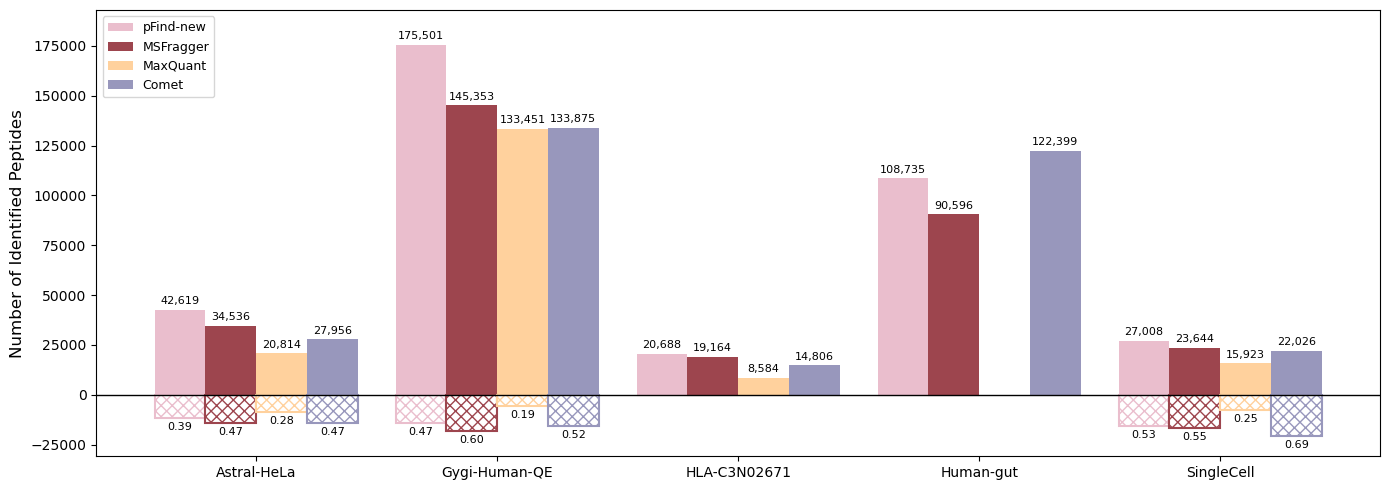

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 数据准备
scaling_factor = 30000
names = ["Astral-HeLa", "Gygi-Human-QE", "HLA-C3N02671", "Human-gut", "SingleCell"]
# 5个簇，每个簇4根柱子（正数数据）
positive_datas = np.array([
    [42619, 34536, 20814, 27956],
    [175501, 145353, 133451, 133875],
    [20688, 19164, 8584, 14806],
    [108735, 90596, 0, 122399],
    [27008, 23644, 15923, 22026]
])
# 负数数据（乘以缩放因子）
negative_datas = np.array([
    [165, 162, 59, 132],
    [823, 878, 257, 702],
    [0, 0, 0, 0],
    [0, 0, 0, 0],
    [142, 131, 40, 151]
])
negative_datas = negative_datas / positive_datas*100

# 修复：标签长度与柱子数量（4）匹配
labels = ["pFind-new", "MSFragger", "MaxQuant", "Comet"]
colors = ["#eabecd", "#9d454e", "#ffd19d", "#9897BC", "#C8B8D4"]

clusters = positive_datas.shape[0]  # 5个簇
bars = positive_datas.shape[1]      # 4根柱子/簇
bar_width = 0.4  # 缩小柱子宽度，避免重叠
colors = colors[:bars]
labels = labels[:bars]
index = np.arange(clusters) * (bar_width * bars + 0.3)  # 簇之间增加间距

# 创建图形
fig, ax = plt.subplots(figsize=(14, 5))

# 绘制正数柱子
for bar_idx in range(bars):
    color = colors[bar_idx]
    # 绘制柱子
    ax.bar(
        index + bar_width * bar_idx, 
        positive_datas[:, bar_idx], 
        bar_width, 
        label=labels[bar_idx],  # 仅首次添加图例（后续通过handlelength=0隐藏重复）
        color=color, 
        align='center'
    )
    # 添加数值标签（跳过0值，避免重叠）
    for cluster_idx in range(clusters):
        val = positive_datas[cluster_idx, bar_idx]
        if val > 0:
            ax.text(
                index[cluster_idx] + bar_idx * bar_width, 
                val + max(positive_datas.flatten()) * 0.01,  # 动态调整标签位置
                f"{val:,}",  # 加千位分隔符
                fontsize=8, 
                ha='center', 
                va='bottom',
            )

# 绘制负数柱子
for bar_idx in range(bars):
    color = colors[bar_idx]
    # 绘制柱子（白色填充+斜线图案+彩色边框）
    ax.bar(
        index + bar_width * bar_idx, 
        -negative_datas[:, bar_idx]*scaling_factor,  # 负数显示在下方
        bar_width, 
        color='white', 
        hatch="xxx", 
        edgecolor=color,
        linewidth=1.5
    )
    # 添加百分比标签（防零错误）
    for cluster_idx in range(clusters):
        neg_val = negative_datas[cluster_idx, bar_idx]
        pos_val = positive_datas[cluster_idx, bar_idx]
        if neg_val > 0 and pos_val > 0:  # 避免除以0
            ax.text(
                index[cluster_idx] + bar_idx * bar_width, 
                -neg_val*scaling_factor - max(negative_datas.flatten())*scaling_factor * 0.1,  # 动态调整位置
                f"{neg_val:.2f}", 
                fontsize=8, 
                ha='center', 
                va='top'
            )

# 优化坐标轴
ax.set_xticks(index + bar_width * (bars - 1) / 2)  # 簇标签居中
ax.set_xticklabels(names, fontsize=10)
# ax.set_ylabel("Entrapped Rate(%)", fontsize=12)
ax.set_ylabel("Number of Identified Peptides", fontsize=12)
ax.set_ylim(
    -max(negative_datas.flatten())*scaling_factor * 1.5,
    max(positive_datas.flatten()) * 1.1     # 正数轴留余量
)

# 优化图例（合并正负柱子标签，避免重复）
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, loc='upper left',  fontsize=9)
# 设置y轴的零刻度线以突出显示
ax.axhline(y=0, color='black',linewidth=1)

plt.tight_layout()
plt.show()

C:\Users\dell\AppData\Local\Temp\ipykernel_27608\3360713023.py:15: RuntimeWarning: invalid value encountered in divide
  ratio_datas = np.array([


[5.55111512e-17 4.00000000e-01 8.00000000e-01 1.20000000e+00] [0.00387151 0.00469076 0.00283463 0.00472171]
[2.1 2.5 2.9 3.3] [0.00468943 0.00604047 0.0019258  0.0052437 ]
[4.2 4.6 5.  5.4] [0. 0. 0. 0.]
[6.3 6.7 7.1 7.5] [0. 0. 0. 0.]
[8.4 8.8 9.2 9.6] [0.0052577  0.00554052        nan 0.00685553]


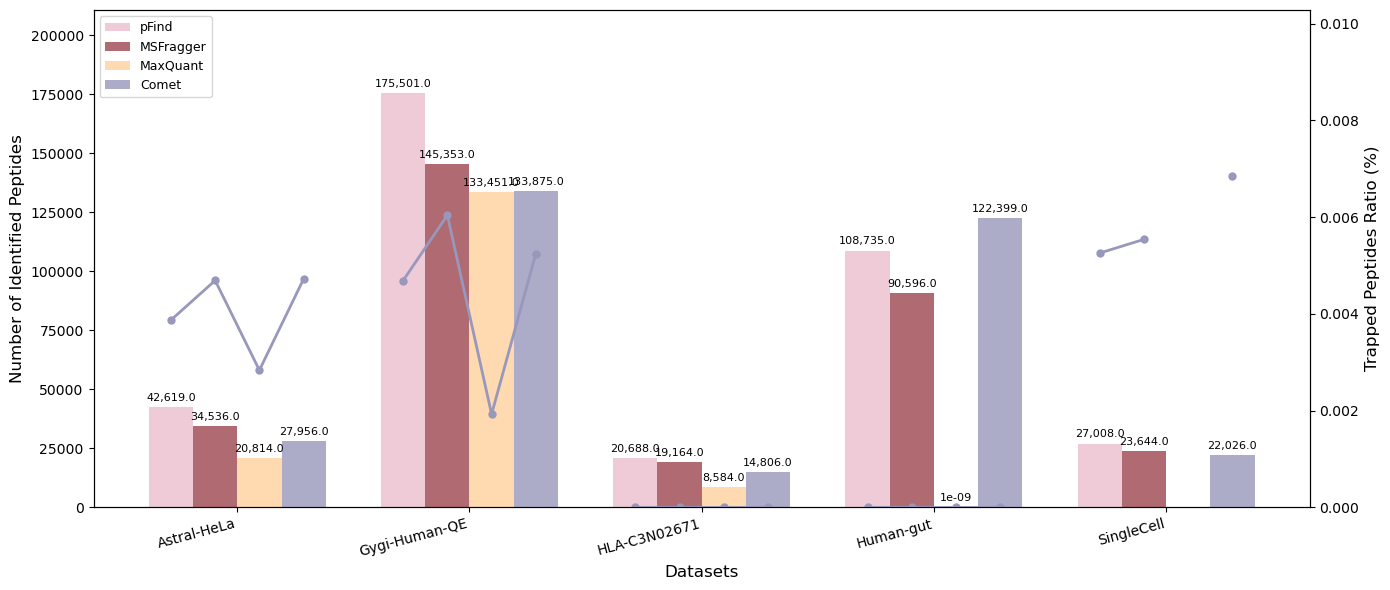

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# 数据准备
names = ["Astral-HeLa", "Gygi-Human-QE", "HLA-C3N02671", "Human-gut", "SingleCell"]
# 左侧Y轴：柱状图数据（肽段数目）
positive_datas = np.array([
    [42619, 34536, 20814, 27956],
    [175501, 145353, 133451, 133875],
    [20688, 19164, 8584, 14806],
    [108735, 90596, 1e-9, 122399],
    [27008, 23644, 0, 22026]
])
# 右侧Y轴：曲线数据（陷阱库比例，%）
ratio_datas = np.array([
    [165, 162, 59, 132],
    [823, 878, 257, 702],
    [0, 0, 0, 0],
    [0, 0, 0, 0],
    [142, 131, 0, 151]
]) / positive_datas


# 标签和颜色（4种工具）
labels = ["pFind", "MSFragger", "MaxQuant", "Comet"]
colors = ["#eabecd", "#9d454e", "#ffd19d", "#9897BC"]

clusters = positive_datas.shape[0]  # 5个簇
bars = positive_datas.shape[1]      # 4种工具
bar_width = 0.4  # 柱子宽度
# 每个簇的中心位置（用于曲线对齐）
cluster_centers = np.arange(clusters) * (bar_width * bars + 0.5) + bar_width * (bars - 1) / 2

# 创建图形和左侧Y轴（柱状图）
fig, ax1 = plt.subplots(figsize=(14, 6))

# 创建右侧Y轴（曲线）
ax2 = ax1.twinx()

# 绘制左侧Y轴：柱状图（肽段数目）
for bar_idx in range(bars):
    color = colors[bar_idx]
    ax1.bar(
        cluster_centers - bar_width*(bars-1)/2 + bar_width*bar_idx,  # 柱子位置对齐簇中心
        positive_datas[:, bar_idx],
        bar_width,
        label=labels[bar_idx],
        color=color,
        alpha=0.8  # 轻微透明，避免遮挡曲线
    )
    # 柱状图数值标签
    for cluster_idx in range(clusters):
        val = positive_datas[cluster_idx, bar_idx]
        if val > 0:
            ax1.text(
                cluster_centers[cluster_idx] - bar_width*(bars-1)/2 + bar_width*bar_idx,
                val + max(positive_datas.flatten())*0.01,
                f"{val:,}",
                fontsize=8,
                ha='center',
                va='bottom'
            )

for idx in range(clusters):
    xs = cluster_centers[idx]+np.array([-2*bar_width,-bar_width,0,bar_width])
    xs += bar_width/2
    ratios = ratio_datas[idx]
    print(xs,ratios)
    ax2.plot(
        xs,
        ratios,
        marker='o',  # 标记点
        markersize=5,
        linewidth=2,
        color=color,
        label=labels[bar_idx] if bar_idx == 0 else ""  # 仅第一个工具添加图例（避免重复）
    )

# # 绘制右侧Y轴：曲线（陷阱库比例）
# for bar_idx in range(bars):
#     color = colors[bar_idx]
#     # 提取当前工具在所有簇的比例值
#     ratios = ratio_datas[:, bar_idx]
#     # 绘制曲线（用标记点+线）
#     ax2.plot(
#         cluster_centers,  # X轴位置与簇中心对齐
#         ratios,
#         marker='o',  # 标记点
#         markersize=5,
#         linewidth=2,
#         color=color,
#         label=labels[bar_idx] if bar_idx == 0 else ""  # 仅第一个工具添加图例（避免重复）
#     )
#     # 曲线数值标签（显示比例）
#     for cluster_idx in range(clusters):
#         ratio_val = ratios[cluster_idx]
#         if ratio_val > 0:
#             ax2.text(
#                 cluster_centers[cluster_idx],
#                 ratio_val + max(ratio_datas.flatten())*0.05,
#                 f"{ratio_val:.2f}%",
#                 fontsize=8,
#                 ha='center',
#                 va='bottom',
#                 color=color
#             )

# 优化X轴
ax1.set_xticks(cluster_centers)  # X轴刻度与簇中心对齐
ax1.set_xticklabels(names, fontsize=10, rotation=15, ha='right')  # 标签旋转避免重叠
ax1.set_xlabel("Datasets", fontsize=12)
ax1.spines['bottom'].set_visible(True)  # 显示X轴

# 左侧Y轴（柱状图）设置
ax1.set_ylabel("Number of Identified Peptides", fontsize=12, color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax1.set_ylim(0, max(positive_datas.flatten()) * 1.2)

# 右侧Y轴（曲线）设置
ax2.set_ylabel("Trapped Peptides Ratio (%)", fontsize=12, color='black')
ax2.tick_params(axis='y', labelcolor='black')
max_ratio = max(ratio_datas.flatten()) if np.any(ratio_datas) else 1
ax2.set_ylim(0, max_ratio * 1.5)

# 合并图例（工具名称）
handles1, labels1 = ax1.get_legend_handles_labels()
ax1.legend(handles1, labels1, loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

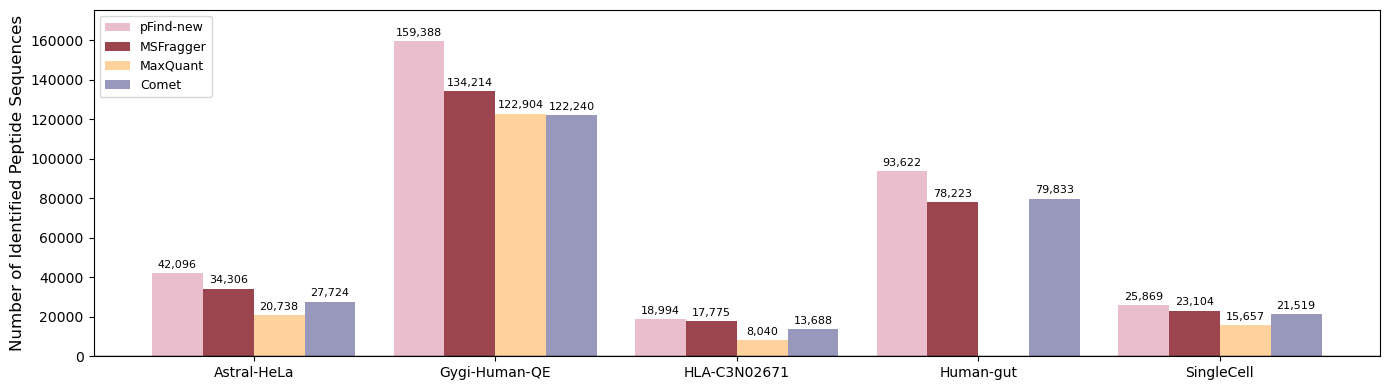

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 数据准备
scaling_factor = 30000
names = ["Astral-HeLa", "Gygi-Human-QE", "HLA-C3N02671", "Human-gut", "SingleCell"]
# 5个簇，每个簇4根柱子（正数数据）
positive_datas = np.array(
    [[42096, 34306, 20738, 27724], 
     [159388, 134214, 122904, 122240], 
     [18994, 17775, 8040, 13688], 
     [93622, 78223, 0, 79833], 
     [25869, 23104, 15657, 21519]]
)

# 修复：标签长度与柱子数量（4）匹配
labels = ["pFind-new", "MSFragger", "MaxQuant", "Comet"]
colors = ["#eabecd", "#9d454e", "#ffd19d", "#9897BC", "#C8B8D4"]

clusters = positive_datas.shape[0]  # 5个簇
bars = positive_datas.shape[1]      # 4根柱子/簇
bar_width = 0.4  # 缩小柱子宽度，避免重叠
colors = colors[:bars]
labels = labels[:bars]
index = np.arange(clusters) * (bar_width * bars + 0.3)  # 簇之间增加间距

# 创建图形
fig, ax = plt.subplots(figsize=(14, 4))

# 绘制正数柱子
for bar_idx in range(bars):
    color = colors[bar_idx]
    # 绘制柱子
    ax.bar(
        index + bar_width * bar_idx, 
        positive_datas[:, bar_idx], 
        bar_width, 
        label=labels[bar_idx],  # 仅首次添加图例（后续通过handlelength=0隐藏重复）
        color=color, 
        align='center'
    )
    # 添加数值标签（跳过0值，避免重叠）
    for cluster_idx in range(clusters):
        val = positive_datas[cluster_idx, bar_idx]
        if val > 0:
            ax.text(
                index[cluster_idx] + bar_idx * bar_width, 
                val + max(positive_datas.flatten()) * 0.01,  # 动态调整标签位置
                f"{val:,}",  # 加千位分隔符
                fontsize=8, 
                ha='center', 
                va='bottom',
            )

# 优化坐标轴
ax.set_xticks(index + bar_width * (bars - 1) / 2)  # 簇标签居中
ax.set_xticklabels(names, fontsize=10)
# ax.set_ylabel("Entrapped Rate(%)", fontsize=12)
ax.set_ylabel("Number of Identified Peptide Sequences", fontsize=12)
ax.set_ylim(
    0,
    max(positive_datas.flatten()) * 1.1     # 正数轴留余量
)

# 优化图例（合并正负柱子标签，避免重复）
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, loc='upper left',  fontsize=9)
# 设置y轴的零刻度线以突出显示
ax.axhline(y=0, color='black',linewidth=1)

plt.tight_layout()
plt.show()

In [158]:
# pFind
pfind = [42096,159388,18994,93622,25869]
# 鉴定到的target肽段数目: 42619
# 其中陷阱库肽段数目: 165
# 鉴定到的target序列数目: 42096

# 鉴定到的target肽段数目: 175501
# 其中陷阱库肽段数目: 823
# 鉴定到的target序列数目: 159388

# 鉴定到的target肽段数目: 20688
# 其中陷阱库肽段数目: 0
# 鉴定到的target序列数目: 18994

# 鉴定到的target肽段数目: 108735
# 其中陷阱库肽段数目: 0
# 鉴定到的target序列数目: 93622

# 鉴定到的target肽段数目: 27008
# 其中陷阱库肽段数目: 142
# 鉴定到的target序列数目: 25869

# MSFragger
msfragger = [34306,134214,17775,78223,23104]
# 鉴定到的target肽段数目: 34536
# 鉴定到的target肽段序列数目: 34306
# 其中陷阱库肽段数目: 162
# decoy肽段数目 0

# 鉴定到的target肽段数目: 145353
# 鉴定到的target肽段序列数目: 134214
# 其中陷阱库肽段数目: 878
# decoy肽段数目 0

# 鉴定到的target肽段数目: 19164
# 鉴定到的target肽段序列数目: 17775
# 其中陷阱库肽段数目: 0
# decoy肽段数目 0

# 鉴定到的target肽段数目: 90596
# 鉴定到的target肽段序列数目: 78223
# 其中陷阱库肽段数目: 0
# decoy肽段数目 0

# 鉴定到的target肽段数目: 23644
# 鉴定到的target肽段序列数目: 23104
# 其中陷阱库肽段数目: 131
# decoy肽段数目 0

# MaxQuant
maxquant = [20738,122904,8040,0,0]
# 鉴定到的target肽段数目: 20814
# 鉴定到的target肽段序列数目: 20738
# 其中陷阱库肽段数目: 59
# decoy肽段数目 62

# 鉴定到的target肽段数目: 133451
# 鉴定到的target肽段序列数目: 122904
# 其中陷阱库肽段数目: 257
# decoy肽段数目 552

# 鉴定到的target肽段数目: 8584
# 鉴定到的target肽段序列数目: 8040
# 其中陷阱库肽段数目: 0
# decoy肽段数目 0


# 鉴定到的target肽段数目: 15923
# 鉴定到的target肽段序列数目: 15657
# 其中陷阱库肽段数目: 40
# decoy肽段数目 137




# Comet
comet = [27724,122240,13688,79833,21519]
# 鉴定到的target肽段数目: 27956
# 其中陷阱库肽段数目: 132
# 鉴定到的target肽段序列数目: 27724

# 鉴定到的target肽段数目: 133875
# 其中陷阱库肽段数目: 702
# 鉴定到的target肽段序列数目: 122240

# 鉴定到的target肽段数目: 14806
# 其中陷阱库肽段数目: 0
# 鉴定到的target肽段序列数目: 13688

# 鉴定到的target肽段数目: 122399
# 其中陷阱库肽段数目: 0
# 鉴定到的target肽段序列数目: 79833

# 鉴定到的target肽段数目: 22026
# 其中陷阱库肽段数目: 151
# 鉴定到的target肽段序列数目: 21519

res = [pfind, msfragger, maxquant, comet]
l = [[],[],[],[],[]]
for i in range(4):
    for j in range(5):
        l[j].append(res[i][j])
print(l)

[[42096, 34306, 20738, 27724], [159388, 134214, 122904, 122240], [18994, 0, 8040, 13688], [93622, 78223, 0, 79833], [25869, 0, 0, 21519]]
